In [1]:
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mticker
from datetime import datetime, timedelta
import os

# ==========================================================
# Paths and settings
# ==========================================================
readdir = '/perm/paaa/IFS/maritime_c'
savedir = '/perm/paaa/images/temp_for_movies'

date = '20250101'

sel_level = 975
average_below_sel_level = False
dt = 3600
deaccumulate_vars = ["p91", "p92"]   # only these will be deaccumulated
vars_to_open = ["p91", "p92", "p93", "p94"]

# ==========================================================
# Colormap and utilities
# ==========================================================
def get_my_colobar():
    cmap = mpl.colors.LinearSegmentedColormap.from_list(
        "", ["#FFFFFF", "#a6cee3", "#1f78b4", "#33a02c", "#fb9a99",
             "#e31a1c", "#fdbf6f", "#ff7f00", "#cab2d6", "#6a3d9a"]
    )
    return cmap


def conditional_formatter(x, _):
    if abs(x) < 0.1:
        return f"{x:.2f}"
    else:
        return f"{x:.1f}"


def deacc_variable(ds, dt=3600):
    """Deaccumulate variable along time dimension."""
    return ds.diff('time') / dt


# ==========================================================
# Experiment setup
# ==========================================================
exp_name = "iv93"
exp_longname = "50r1, dryMF (2x momentum, 2x scalars) allPBL"

# ==========================================================
# Read and preprocess data
# ==========================================================
ds_dict = {}
lon2d_dict = {}
lat2d_dict = {}

for var in vars_to_open:
    file = f"{readdir}/hres_{exp_name}_{var}_pl_{date}_tropics.nc"
    print(f"Loading {file}")

    with xr.open_dataset(file, engine="h5netcdf", chunks={}, decode_cf=False) as tmp:
        all_vars = list(tmp.variables.keys())
    keep_vars = [var, "latitude", "longitude", "level", "time"]
    drop_vars = [v for v in all_vars if v not in keep_vars]

    ds = xr.open_dataset(
        file,
        engine="h5netcdf",
        chunks={},
        decode_cf=True,
        drop_variables=drop_vars
    )[var]

    # --- Select or average vertical levels ---
    if average_below_sel_level:
        ds_sel = ds.sel(level=slice(1000, sel_level)).mean(dim='level')
    else:
        ds_sel = ds.sel(level=sel_level, method='nearest')

    # --- Deaccumulate only for selected variables ---
    if var in deaccumulate_vars:
        print(f"Deaccumulating {var} with dt={dt} seconds")
        ds_sel = deacc_variable(ds_sel, dt=dt)
        ds_sel = ds_sel * 3600  # [per second] → [per hour]
    else:
        print(f"Skipping deaccumulation for {var}")

    ds_dict[var] = ds_sel.chunk({"time": 1, "latitude": 100, "longitude": 100})
    lon, lat = ds_sel.longitude, ds_sel.latitude
    lon2d_dict[var], lat2d_dict[var] = np.meshgrid(lon, lat)

# ==========================================================
# Plotting setup
# ==========================================================
min_lon, max_lon = 120, 180
min_lat, max_lat = -20, 20

start_time = datetime.strptime("01.01.2025, 00 UTC", "%d.%m.%Y, %H UTC")
ntime = len(next(iter(ds_dict.values())).time)
time_labels = [(start_time + timedelta(hours=i)).strftime("%d.%m.%Y, %H UTC")
               for i in range(ntime)]

cmap = get_my_colobar()




Loading /perm/paaa/IFS/maritime_c/hres_iv93_p91_pl_20250101_tropics.nc
Deaccumulating p91 with dt=3600 seconds
Loading /perm/paaa/IFS/maritime_c/hres_iv93_p92_pl_20250101_tropics.nc
Deaccumulating p92 with dt=3600 seconds
Loading /perm/paaa/IFS/maritime_c/hres_iv93_p93_pl_20250101_tropics.nc
Skipping deaccumulation for p93
Loading /perm/paaa/IFS/maritime_c/hres_iv93_p94_pl_20250101_tropics.nc
Skipping deaccumulation for p94



Plotting timestep 90
  -> Plotting p91
  -> Plotting p92
  -> Plotting p93
  -> Plotting p94


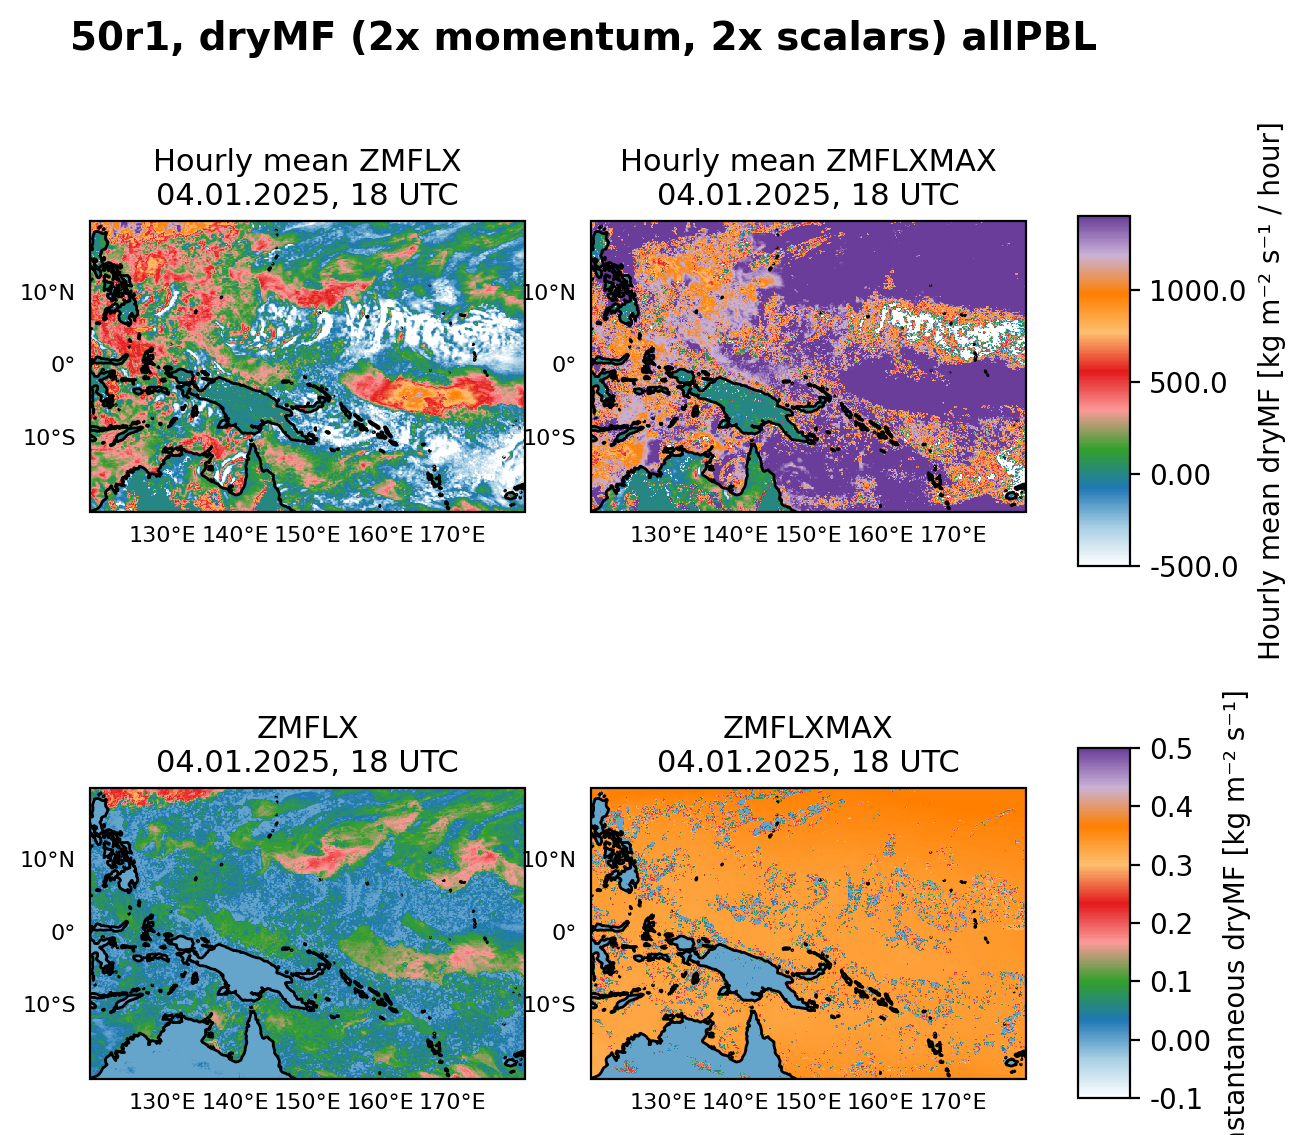

In [ ]:
# ==========================================================
# Plot each time step
# ==========================================================
var_titles = {
    "p91": "Hourly mean ZMFLX",
    "p92": "Hourly mean ZMFLXMAX",
    "p93": "ZMFLX",
    "p94": "ZMFLXMAX"
}

for t in [90]:
    print(f"\nPlotting timestep {t}")

    fig, ax = plt.subplots(nrows=2, ncols=2, dpi=200,
                           subplot_kw={'projection': ccrs.PlateCarree()},
                           figsize=(13, 7))
    axes = ax.flatten()

    data_t = {v: ds_dict[v].isel(time=t).compute() for v in vars_to_open}

    # shared vmin/vmax for p91 and p92
    vmin12 = -500
    vmax12 = 1400
    # shared vmin/vmax for p93 and p94
    vmin34 = -0.1
    vmax34 = 0.5

    pcm_list = []
    for i, var in enumerate(vars_to_open):
        print(f"  -> Plotting {var}")
        d = data_t[var]
        extent = [min_lon, max_lon, min_lat, max_lat]
        ax = axes[i]
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        if var in ["p91", "p92"]:
            pcm = ax.pcolormesh(lon2d_dict[var], lat2d_dict[var], d,
                                shading='nearest', cmap=cmap,
                                vmin=vmin12, vmax=vmax12,
                                transform=ccrs.PlateCarree())
        else:
            pcm = ax.pcolormesh(lon2d_dict[var], lat2d_dict[var], d,
                                shading='nearest', cmap=cmap,
                                vmin=vmin34, vmax=vmax34,
                                transform=ccrs.PlateCarree())

        pcm_list.append(pcm)
        ax.set_title(f"{var_titles[var]}\n{time_labels[t]}", fontsize=11)
        ax.coastlines(color='black')

        gl = ax.gridlines(draw_labels=True)
        gl.xlocator = mticker.FixedLocator(range(-180, 181, 10))
        gl.ylocator = mticker.FixedLocator(range(-90, 91, 10))
        gl.xlines = False
        gl.ylines = False
        gl.top_labels = False
        gl.right_labels = False
        gl.bottom_labels = True
        gl.left_labels = True
        gl.xlabel_style = {'size': 8}
        gl.ylabel_style = {'size': 8}

    # --- Colourbars ---
    # Shorter and aligned with each row
    cbar_ax1 = fig.add_axes([0.46, 0.55, 0.02, 0.25])  # right of top row
    cbar1 = fig.colorbar(pcm_list[0], cax=cbar_ax1)
    cbar1.set_label("kg m⁻² s⁻¹ / hour]", fontsize=10)
    cbar1.ax.yaxis.set_major_formatter(FuncFormatter(conditional_formatter))

    cbar_ax2 = fig.add_axes([0.46, 0.17, 0.02, 0.25])  # right of bottom row
    cbar2 = fig.colorbar(pcm_list[2], cax=cbar_ax2)
    cbar2.set_label("[kg m⁻² s⁻¹]", fontsize=10)
    cbar2.ax.yaxis.set_major_formatter(FuncFormatter(conditional_formatter))

    # --- Common title ---
    fig.suptitle(exp_longname, fontsize=14, fontweight='bold', y=0.94, x=0.27)

    # tighter spacing between rows
    fig.subplots_adjust(bottom=0.1, top=0.88, left=0.08, right=0.44,
                        wspace=0.15, hspace=0.08)

    # tag = f"{sel_level}hPa"
    # plt.savefig(f"{savedir}/map_{exp_name}_{tag}_{date}_{t:03d}.png")
    # plt.close()


In [9]:
# ==========================================================
# Plot each time step
# ==========================================================
# for t in range(ntime):
for t in [90]:
    print(f"\nPlotting timestep {t}")

    fig, ax = plt.subplots(nrows=2, ncols=2, dpi=200,
                           subplot_kw={'projection': ccrs.PlateCarree()},
                           figsize=(14, 8))
    axes = ax.flatten()

    # --- Load all variables for this timestep ---
    data_t = {v: ds_dict[v].isel(time=t).compute() for v in vars_to_open}

    # --- Compute colour scales ---
    # shared vmin/vmax for p91 and p92
    vmin12 = -500
    vmax12 = 1400
    # shared vmin/vmax for p93 and p94
    vmin34 = -0.1
    vmax34 = 0.5

    pcm_list = []
    for i, var in enumerate(vars_to_open):
        print(f"  -> Plotting {var}")
        d = data_t[var]
        extent = [min_lon, max_lon, min_lat, max_lat]
        axes[i].set_extent(extent, crs=ccrs.PlateCarree())

        if var in ["p91", "p92"]:
            pcm = axes[i].pcolormesh(lon2d_dict[var], lat2d_dict[var], d,
                                     shading='nearest', cmap=cmap,
                                     vmin=vmin12, vmax=vmax12,
                                     transform=ccrs.PlateCarree())
        else:
            pcm = axes[i].pcolormesh(lon2d_dict[var], lat2d_dict[var], d,
                                     shading='nearest', cmap=cmap,
                                     vmin=vmin34, vmax=vmax34,
                                     transform=ccrs.PlateCarree())

        pcm_list.append(pcm)
        axes[i].set_title(f"{var}, {time_labels[t]}", fontsize=11)
        axes[i].coastlines(color='black')

        gl = axes[i].gridlines(draw_labels=True)
        gl.xlocator = mticker.FixedLocator(range(-180, 181, 10))
        gl.ylocator = mticker.FixedLocator(range(-90, 91, 10))
        gl.xlines = False
        gl.ylines = False
        gl.top_labels = False
        gl.right_labels = False
        gl.bottom_labels = True
        gl.left_labels = True
        gl.xlabel_style = {'size': 9}
        gl.ylabel_style = {'size': 9}

    # --- Two colour bars ---
    # one for p91/p92
    cbar_ax1 = fig.add_axes([0.46, 0.52, 0.02, 0.31])  # right of top row
    cbar1 = fig.colorbar(pcm_list[0], cax=cbar_ax1)
    cbar1.set_label("Hourly mean dryMF [kg m⁻² s⁻¹ / hour]", fontsize=10)
    cbar1.ax.yaxis.set_major_formatter(FuncFormatter(conditional_formatter))

    # one for p93/p94
    cbar_ax2 = fig.add_axes([0.46, 0.1, 0.02, 0.31])  # right of bottom row
    cbar2 = fig.colorbar(pcm_list[2], cax=cbar_ax2)
    cbar2.set_label("Istantaneous dryMF [kg m⁻² s⁻¹]", fontsize=10)
    cbar2.ax.yaxis.set_major_formatter(FuncFormatter(conditional_formatter))

    # --- Common title ---
    fig.suptitle(f"{exp_longname}", fontsize=14, fontweight='bold', y=0.92,x=0.27)
    fig.subplots_adjust(bottom=0.1, top=0.9, left=0.08, right=0.44,
                        wspace=0.15, hspace=0.18)
    
    # tag = f"{sel_level}hPa"
    # plt.savefig(f"{savedir}/map_{exp_name}_{tag}_{date}_{t:03d}.png")
    # plt.close()


Plotting timestep 90
  -> Plotting p91
  -> Plotting p92
  -> Plotting p93
  -> Plotting p94


: 

: 

: 

##OLD